# **Project Name**    -



##### **Project Type**    - EDA
##### **Contribution**    - Individual/Team
##### **Team Member 1 -** Eepsa Ranjan

# **Project Summary -**

This project presents an exploratory data analysis (EDA) of a Nykaa product dataset, originally containing 625 products across 18 columns. Nykaa is a leading Indian beauty and personal care e-commerce platform, and this dataset captures product-level details including brand, category, price, description, rating, and review count. The objective was to uncover meaningful patterns in pricing, customer satisfaction, and brand/category performance to generate actionable business insights.
The project began with a "Know Your Data" phase, examining the dataset's structure, duplicates, and missing values. Two immediate data quality issues surfaced: Product Price and Product Rating were stored as text instead of numbers, and a few rows had corrupted price values (containing product descriptions instead of numeric prices). These were cleaned using pd.to_numeric() with error coercion, and 15 rows with unresolved invalid prices were dropped, leaving 610 clean rows. Missing values elsewhere were handled thoughtfully — filled with clear labels like "Not Specified" or zero, based on what the absence likely meant, rather than dropped outright. A simplified Main Category column was also created from the original nested category path to make category-level analysis manageable. Two internal metadata columns (Expected Category Count, Expected Brand Count) were dropped as not relevant to the core analysis.
With clean data in place, 15 charts were built following a Univariate → Bivariate → Multivariate structure. Univariate analysis showed the catalog is dominated by low-priced products (majority under ₹500), that ratings cluster strongly between 4–4.5 (aside from many unrated products), and that a small set of bestsellers accounts for most reviews while most products remain under-reviewed.
Bivariate analysis revealed one of the project's most important findings: price does not predict rating. In fact, products priced ₹1000–2000 showed a clear rating dip, and expensive products consistently received far fewer reviews than cheap ones — suggesting a trust and visibility gap rather than lower demand. At the brand level, Inner Sense stood out as the most expensive top-10 brand yet also the lowest-rated overall.
Multivariate analysis dug deeper into these patterns. It pinpointed that Inner Sense's poor performance was driven almost entirely by its Mom & Baby line, rated just 0.4 — a serious concern given how trust-sensitive baby products are. It also localized the price-rating dip specifically to high-priced Skin products, while confirming this was based on a small sample (8–10 products), tempering the urgency without dismissing the concern. A correlation heatmap and pair plot confirmed these relationships were weak but real, and visually tied together the entire analysis.
The project concludes that Nykaa's core strength lies in its affordable product segment, which enjoys both high ratings and high engagement. However, specific risk areas were identified — most notably the Inner Sense/Mom & Baby issue — that require urgent attention. Categories like Mom & Baby, Health & Wellness, and Appliances also had too few products to draw reliable conclusions and would benefit from catalog expansion. Overall, the analysis recommends treating pricing and quality as separate business levers, since higher prices did not translate into higher customer satisfaction anywhere in this dataset.

# **GitHub Link -**

https://github.com/eepsaranjan/Nykaa-EDA.git

# **Problem Statement**


Nykaa hosts a large catalog of beauty and personal care products across multiple brands and categories. This project analyzes 610 Nykaa products to understand patterns in pricing, ratings, reviews, categories, and brands — with the goal of identifying pricing-quality mismatches and flagging categories or brands that may need attention.

#### **Define Your Business Objective?**

To use exploratory data analysis to determine:

1. How pricing is distributed across the catalog, and what that says about market positioning.
2. Whether price influences customer rating, or if the two are unrelated.
3. Which categories/brands perform best or worst in ratings, and where reputational risks exist.
4. How customer engagement (reviews) relates to price and category.

These insights aim to support decisions on pricing strategy, brand partnerships, and quality/review-generation efforts to improve customer satisfaction and identify growth opportunities.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [3]:
# Load Dataset
path='/content/drive/MyDrive/Colab Notebooks/Data Set/Nykaa_Product_Review.csv'
df=pd.read_csv(path)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [5]:
# Dataset First Look
df.head()

,Product Id,Product Brand Code,Retailer,Product Category,Product Brand,Product Name,Product Price,Product Url,Market,Product Description,Product Currency,Product Image Url,Product Tags,Product Contents,Product Rating,Product Reviews Count,Expected Category Count,Expected Brand Count
0,b77f3da33be6e65f6183da6ada8c07ca,BZ1000,nykaa.com,Makeup > Face > Contour,ETUDE HOUSE,ETUDE HOUSE Face Color Shading - 02,600,https://www.nykaa.com/c/p/760922?skuId=760920,IN,Etude House Face Color Shading provides a shad...,INR,https://images-static.nykaa.com/media/catalog/...,"ETUDE HOUSE Face Color Shading - 02, Makeup, F...",NaN,4.6,4.0,153,82
1,f54658c5d511195b6621a640fb743b1b,BH5931,nykaa.com,Brand > L'Oreal Paris,L'Oreal Paris,L'Oreal Paris Glow Mon Amour Highlighting Drop...,454,https://www.nykaa.com/c/p/565974?skuId=565973,IN,It's time to skip the snooze button and get up...,INR,https://images-static.nykaa.com/media/catalog/...,L'Oreal Paris Glow Mon Amour Highlighting Drop...,"G927637, Cyclopentasiloxane, Dimethicone, Isod...",4.3,147.0,431,431
2,cdf6b3387f8976c8e38ad150173dbb6d,BH7276,nykaa.com,Makeup > Face > Foundation,The Body Shop,The Body Shop All-In-One Face Base - 045,1395,https://www.nykaa.com/c/p/31142?skuId=30050,IN,Note: The Body Shop products will be dispatche...,INR,https://images-static.nykaa.com/media/catalog/...,"The Body Shop All-In-One Face Base - 045 , Mak...",NaN,4.4,58.0,0,0
3,424755c11c78b2b24ff13c675baf5d19,BZ1000,nykaa.com,Health & Wellness > Good for You > Super Food,True Elements,True Elements Sunflower Raw Seeds,175,https://www.nykaa.com/c/p/370883?skuId=370881,IN,Sunflower has always been admired for its beau...,INR,https://images-static.nykaa.com/media/catalog/...,"True Elements Sunflower Raw Seeds, Wellness, S...",Raw Sunflower Seeds,5,0.0,389,149
4,f7f76573099db0058ef5264c35d9d02e,BZ1000,nykaa.com,Makeup > Lips > Lip Stain,Nykaa Cosmetics,Nykaa Wonderpuff Cushion Liquid Lipstick - Wer...,539,https://www.nykaa.com/c/p/555315?skuId=555310,IN,It's no secret that a good lippie is a real mo...,INR,https://images-static.nykaa.com/media/catalog/...,NykaaÂ Wonderpuff!Â LipÂ &Â CheekÂ Cushion Lip...,NaN,4,934.0,80,436


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
df.shape

(625, 18)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product Id               625 non-null    object 
 1   Product Brand Code       625 non-null    object 
 2   Retailer                 625 non-null    object 
 3   Product Category         544 non-null    object 
 4   Product Brand            625 non-null    object 
 5   Product Name             625 non-null    object 
 6   Product Price            625 non-null    object 
 7   Product Url              610 non-null    object 
 8   Market                   625 non-null    object 
 9   Product Description      625 non-null    object 
 10  Product Currency         625 non-null    object 
 11  Product Image Url        625 non-null    object 
 12  Product Tags             610 non-null    object 
 13  Product Contents         324 non-null    object 
 14  Product Rating           5

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(2)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
m=df.isnull().sum()
m

,0
Product Id,0
Product Brand Code,0
Retailer,0
Product Category,81
Product Brand,0
Product Name,0
Product Price,0
Product Url,15
Market,0
Product Description,0


Text(0, 0.5, 'Number of Missing Values')

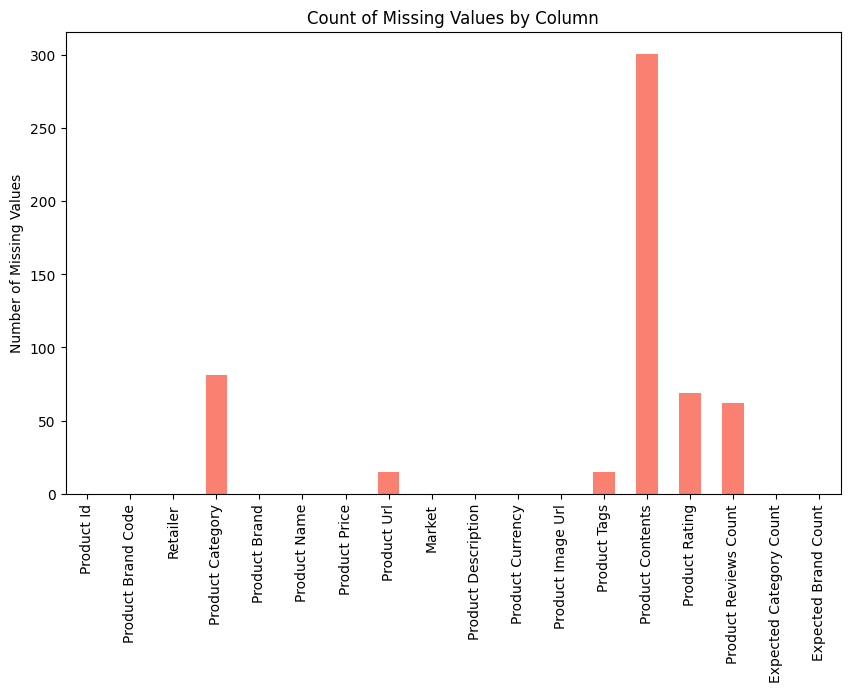

In [10]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
m.plot(kind='bar', color='salmon')
plt.title('Count of Missing Values by Column')
plt.ylabel('Number of Missing Values')

### What did you know about your dataset?

The dataset contains 625 records and 18 columns, scraped from Nykaa.com (an Indian beauty and skincare shopping website). Each row is one product. The columns can be grouped into simple categories:
*   IDs – things that identify the product, like Product Id and Product Brand Code
*   Product details – name, brand, category, description, tags
*   Price info – price, currency, market, retailer
*   Links/images – product URL, image URL
*   Popularity info – rating and number of reviews

6 columns have missing data.
The biggest gap is in Product Contents (missing for about half the products).



## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['Product Id', 'Product Brand Code', 'Retailer', 'Product Category',
       'Product Brand', 'Product Name', 'Product Price', 'Product Url',
       'Market', 'Product Description', 'Product Currency',
       'Product Image Url', 'Product Tags', 'Product Contents',
       'Product Rating', 'Product Reviews Count', 'Expected Category Count',
       'Expected Brand Count'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,Product Reviews Count,Expected Brand Count
count,563.00000,625.000000
mean,357.20444,130.012800
std,1062.46027,276.976406
min,0.00000,0.000000
25%,3.00000,0.000000
50%,21.00000,0.000000
75%,141.50000,137.000000
max,8513.00000,2096.000000


### Variables Description

* Product Id – A unique code for each product listing.
* Product Brand Code – A short code representing the brand (e.g., "BZ1000").
* Retailer – The website selling the product (all values are "nykaa.com" here).
* Product Category – The category path the product belongs to, like "Makeup > Face > Contour."
* Product Brand – The brand name of the product, like "L'Oreal Paris" or "The Body Shop."
* Product Name – The full name of the product as listed on the site.
* Product Price – The listed price of the product.
* Product Url – The web link to the product's page.
* Market – The country/region the product is sold in (e.g., "IN" for India).
* Product Description – A short text description of the product.
* Product Currency – The currency the price is in (e.g., "INR").
* Product Image Url – A link to the product's image.
* Product Tags – Keywords or labels associated with the product.
* Product Contents – Details about what's included with the product.
* Product Rating – The average customer rating for the product.
* Product Reviews Count – The total number of reviews the product has received.
* Expected Category Count – A field likely used for data-quality checks on category values.
* Expected Brand Count – A field likely used for data-quality checks on brand values.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

Product Id: 573
Product Brand Code: 48
Retailer: 3
Product Category: 171
Product Brand: 246
Product Name: 581
Product Price: 336
Product Url: 573
Market: 16
Product Description: 583
Product Currency: 16
Product Image Url: 576
Product Tags: 567
Product Contents: 294
Product Rating: 32
Product Reviews Count: 230
Expected Category Count: 170
Expected Brand Count: 137


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.
# Convert Product Price to numeric
df['Product Price'] = pd.to_numeric(df['Product Price'], errors='coerce')

# Convert Product Rating to numeric
df['Product Rating'] = pd.to_numeric(df['Product Rating'], errors='coerce')

# Extract the main category (before the first ">")
df['Main Category'] = df['Product Category'].str.split('>').str[0].str.split().str.join(' ')

# Fill missing values
df['Product Category'] = df['Product Category'].fillna('Not Specified')
df['Main Category'] = df['Main Category'].fillna('Not Specified')
df['Product Contents'] = df['Product Contents'].fillna('Not Available')
df['Product Rating'] = df['Product Rating'].fillna(0)
df['Product Reviews Count'] = df['Product Reviews Count'].fillna(0)

# Drop columns not needed for analysis
df = df.drop(columns=['Expected Category Count', 'Expected Brand Count'])

In [15]:
df['Product Price'].isnull().sum()

np.int64(15)

In [16]:
df = df.dropna(subset=['Product Price'])

In [17]:
df['Product Rating'].isnull().sum()

np.int64(0)

In [18]:
# Check the result
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 610 entries, 0 to 624
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product Id             610 non-null    object 
 1   Product Brand Code     610 non-null    object 
 2   Retailer               610 non-null    object 
 3   Product Category       610 non-null    object 
 4   Product Brand          610 non-null    object 
 5   Product Name           610 non-null    object 
 6   Product Price          610 non-null    float64
 7   Product Url            610 non-null    object 
 8   Market                 610 non-null    object 
 9   Product Description    610 non-null    object 
 10  Product Currency       610 non-null    object 
 11  Product Image Url      610 non-null    object 
 12  Product Tags           610 non-null    object 
 13  Product Contents       610 non-null    object 
 14  Product Rating         610 non-null    float64
 15  Product Rev

### What all manipulations have you done and insights you found?

Manipuations performed:


1.   Converted Product Price to numeric
2.   Converted Product Rating to numeric
3.   Created a new Main Category column – extracted the top-level category from the Product Category path (e.g., "Makeup > Face > Contour" → "Makeup") to make grouping and charting simpler, since the original column had too many unique combinations to visualize meaningfully.
4.    Handled missing values: Product Category, Main Category → filled with "Not Specified" Product Contents → filled with "Not Available" Product Rating, Product Reviews Count → filled with 0
5.    Dropped Expected Category Count and Expected Brand Count – these fields appeared to be scrape-related metadata rather than genuine product attributes, and weren't relevant to the core product/price/rating analysis, so they were removed to keep the dataset focused.

Insights found during wrangling:

* A small number of rows had corrupted Product Price values, where the price field contained unrelated description text instead of a number. Since these were coerced to NaN, missing data rows were dropped.
* After cleaning, Product Price and Product Rating are fully numeric and ready for univariate and bivariate analysis.
* Dropping Expected Category Count and Expected Brand Count simplifies the dataset to focus on customer-facing attributes (price, rating, category, brand) rather than internal scrape-quality metadata.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

Text(0, 0.5, 'Number of Products')

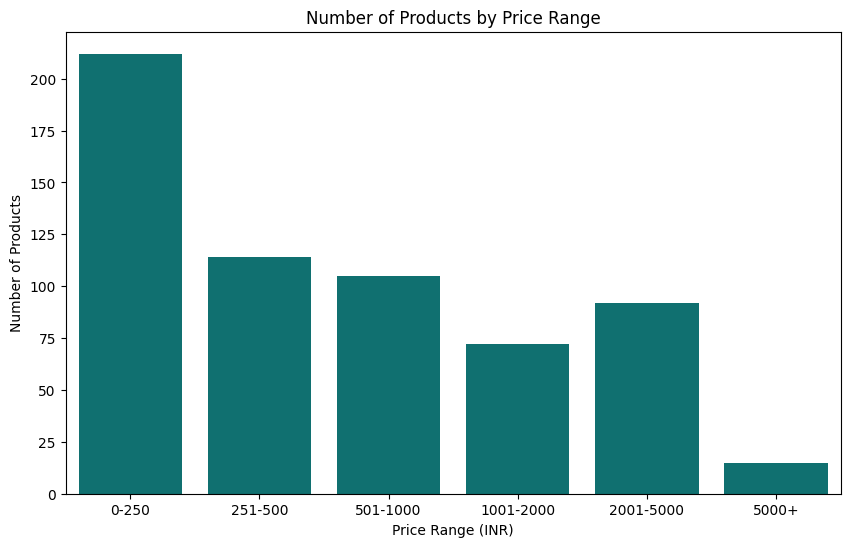

In [19]:
# Chart - 1 visualization code
bins = [0, 250, 500, 1000, 2000, 5000, df['Product Price'].max()]
labels = ['0-250', '251-500', '501-1000', '1001-2000', '2001-5000', '5000+']
df['Price Range'] = pd.cut(df['Product Price'], bins=bins, labels=labels)

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Price Range', color='teal')
plt.title('Number of Products by Price Range')
plt.xlabel('Price Range (INR)')
plt.ylabel('Number of Products')

In [20]:
# Check for zero or suspiciously low prices
print((df['Product Price'] == 0).sum())
df[df['Product Price'] < 50].sort_values('Product Price').head(10)

0


,Product Id,Product Brand Code,Retailer,Product Category,Product Brand,Product Name,Product Price,Product Url,Market,Product Description,Product Currency,Product Image Url,Product Tags,Product Contents,Product Rating,Product Reviews Count,Main Category,Price Range
486,3a6684e3a584d25f731f13c05284fc67,BZ1000,nykaa.com,Personal Care > Hands & Feet > Hand Sanitizer,Godrej Protekt,Godrej Protekt Germ Protection Hand Sanitizer,25.0,https://www.nykaa.com/c/p/802122?skuId=807474,IN,Godrej Protekt Germ Protection Hand Sanitizer ...,INR,https://images-static.nykaa.com/media/catalog/...,Godrej Protekt Germ Protection Hand Sanitizer ...,Ethyl Alcohol 95% (v/v) I.P. ( Denatured with ...,4.4,70.0,Personal Care,0-250
448,18901030656771890103000000300000000000LRLE77AIN,BH0302,nykaa.com,Skin > Body Care > Soaps,Liril,Liril Lemon & Tea Tree Soap Oil,32.0,https://www.nykaa.com/c/p/415721?skuId=415720,IN,"The new Liril Lemon & Tea Tree Soap, with its ...",INR,https://images-static.nykaa.com/media/catalog/...,"Liril Lemon & Tea Tree Soap, Bath & Body, Bath...","Sodium Palmate, Sodium Palm Kernelate, Water, ...",4.4,34.0,Skin,0-250
87,8c369e49f7cbd2d315e33fea77d1b840,BH6523,nykaa.com,Hair > Shop By Concern > Color Protection,Himalaya,Himalaya Herbals Protein Hair Cream,33.0,https://www.nykaa.com/c/p/523053?skuId=523052,IN,"A natural hair cream full of goodness, Himalay...",INR,https://images-static.nykaa.com/media/catalog/...,"Himalaya Herbals Protein Hair Cream, Herbal, H...","Key Ingredients:Amla, a natural hair tonic use...",4.2,959.0,Hair,0-250
115,b5be07eeaac9542dff8cdeb64898fe8a,BZ1000,nykaa.com,Health & Wellness > Sexual Wellness > Condoms,KamaSutra,Kamasutra Long Last Condoms - 3pcs,40.0,https://www.nykaa.com/c/p/483968?skuId=483770,IN,KamaSutra Longlast Condoms are designed to hel...,INR,https://images-static.nykaa.com/media/catalog/...,"Kamasutra Long Last Condoms, Wellness, Sexual ...",Not Available,4.1,1.0,Health & Wellness,0-250
605,a908b31d1f5de8ee26f38a270eb6b4e6,BH6523,nykaa.com,Brand > Himalaya,Himalaya,Himalaya Men Daily Nourish Hair Cream,41.0,https://www.nykaa.com/c/p/716145?skuId=716143,IN,"A natural hair cream full of goodness, Himalay...",INR,https://images-static.nykaa.com/media/catalog/...,Himalaya Men Natural Bright Oil Control Face G...,Massage the Protein Hair Cream gently on scalp...,4.5,0.0,Brand,0-250
24,5be896155cd4045dbaac2c008f007d57,BH6523,nykaa.com,Mom & Baby > Baby Care > Wipes & Buds,Himalaya,Himalaya Gentle Baby Wipes 12's,44.0,https://www.nykaa.com/c/p/6007?skuId=151749,IN,Clean your baby's skin with utmost gentleness ...,INR,https://images-static.nykaa.com/media/catalog/...,"Himalaya Baby Care Gentle Baby Wipes, Mom & Ba...",Key Ingredient Information: Indian Aloe: India...,4.5,80.0,Mom & Baby,0-250
481,a9f0efd23c20338908f52a330f014bcf,BZ1000,nykaa.com,Skin > Body Care > Soaps,Denver,Denver Black Code Soap for Men,45.0,https://www.nykaa.com/c/p/59489?skuId=59491,IN,Rejuvenate your senses with the freshness of D...,INR,https://images-static.nykaa.com/media/catalog/...,"Denver Black Code Soap for Men, Fragrance, Men...",Not Available,4.3,15.0,Skin,0-250
190,5c1831736371d86da36dc910e3f70958,BH0925,nykaa.com,Skin > Shop By Concern > Skin Brightening,Olivia,Olivia Herb Bleach,45.0,https://www.nykaa.com/c/p/465052?skuId=733788,IN,Introducing the first gentle bleach for sensit...,INR,https://images-static.nykaa.com/media/catalog/...,"Olivia Herb Bleach (60gm), Skin, Masks, Masks ...","Aqua, Hydrogen peroxide (4.25% w/w)*, Ammonium...",4.4,73.0,Skin,0-250
593,2f35a3b71b61319f44ce520ddb8f15bf,BZ1000,nykaa.com,Natural > Makeup > Lip Balm & Gloss,Vaadi Herbals,Vaadi Herbals Lychee Lip Therapy,48.0,https://www.nykaa.com/c/p/19762?skuId=11403,IN,PRO-TIP: Clean Lip Gently And Use Your Fingers...,INR,https://images-static.nykaa.com/media/catalog/...,"Vaadi Herbals Lychee Lip Therapy,Herbals,Skinc...",Lychee : Improves Circulation. Adds Health & G...,4.4,612.0,Natural,0-250
338,1e695cfb6162fcdaf1a3125d37a0ba95,BZ1000,nykaa

##### 1. Why did you pick the specific chart?

Grouping prices into clear, business-friendly buckets (₹0–250, ₹251–500, etc.) and plotting them as a bar chart makes the spread of pricing across the catalog much easier to read and communicate, especially to a non-technical audience.

##### 2. What is/are the insight(s) found from the chart?

The majority of products fall in the lower price brackets (₹0–500), with the number of products steadily decreasing as price increases. Very few products are priced above ₹2000, and products above ₹5000 are rare outliers in the catalog.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact: This confirms that Nykaa's catalog (in this sample) is dominated by affordable, mass-market products rather than premium/luxury items. This has direct implications for business strategy:

* Marketing & promotions should focus heavily on the ₹0–500 range, since that's where the bulk of the catalog — and likely bulk of transactions — lies.
* Premium products (₹2000+) may need different positioning (e.g., highlighted as "luxury picks" or bundled with lower-cost items) since they represent a small share of the catalog and may need more visibility to sell.
* Most of the products (₹0–500) are low-priced. Low-priced products usually earn less profit per sale. This means the business is depending a lot on selling a large number of cheap products to make money, instead of earning more from a smaller number of expensive ones.
The risk here is: if people suddenly buy less (say, during a slow season or increased competition), there aren't many higher-priced products to fall back on to keep profits steady. So while low prices attract more buyers, they also make the business's income less stable in the long run.

#### Chart - 2

Text(0, 0.5, 'Number of Products')

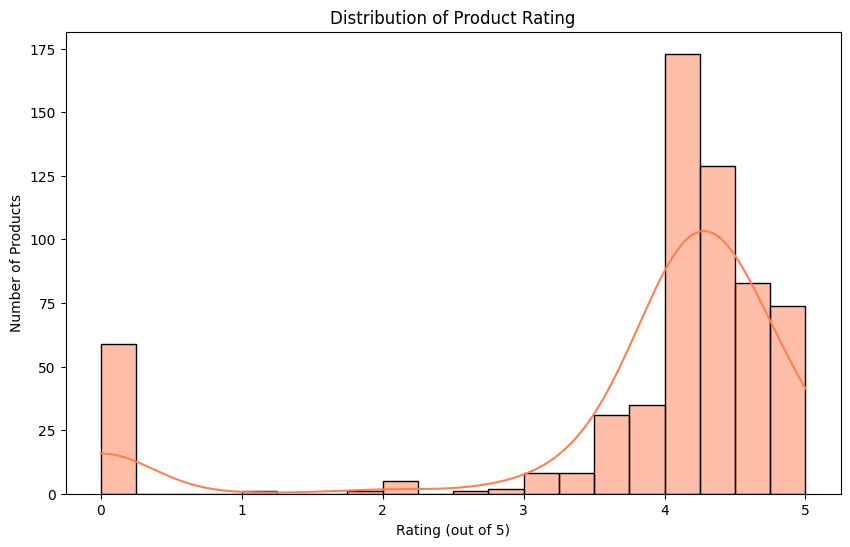

In [21]:
# Chart - 2 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df['Product Rating'], bins=20, kde=True, color='coral')
plt.title('Distribution of Product Rating')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of Products')

##### 1. Why did you pick the specific chart?

A histogram is the right choice here, since Product Rating is a single continuous numeric variable. It shows how ratings are spread across the catalog — whether most products are rated highly, poorly, or somewhere in the middle — and helps spot patterns like clustering near 0 (unrated products) or near 5 (highly rated products).

##### 2. What is/are the insight(s) found from the chart?

The chart shows a clear spike of about 59 products at 0 rating — these are unrated products, not genuinely bad ones. Excluding that spike, ratings are heavily concentrated between 4 and 5, with the biggest cluster around 4–4.5 (over 170 products). Very few products fall in the 1–3 range — customers rarely leave a middling review; they either haven't reviewed yet, or they rate quite high.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:
* Products stuck at 0 rating may need a push strategy (featured placement, discounts, review incentives) to get their first reviews and build trust.
* Worth checking separately: how many products have a genuinely low rating (say, below 3) — those would need product-quality investigation

#### Chart - 3

Text(0, 0.5, 'Main Category')

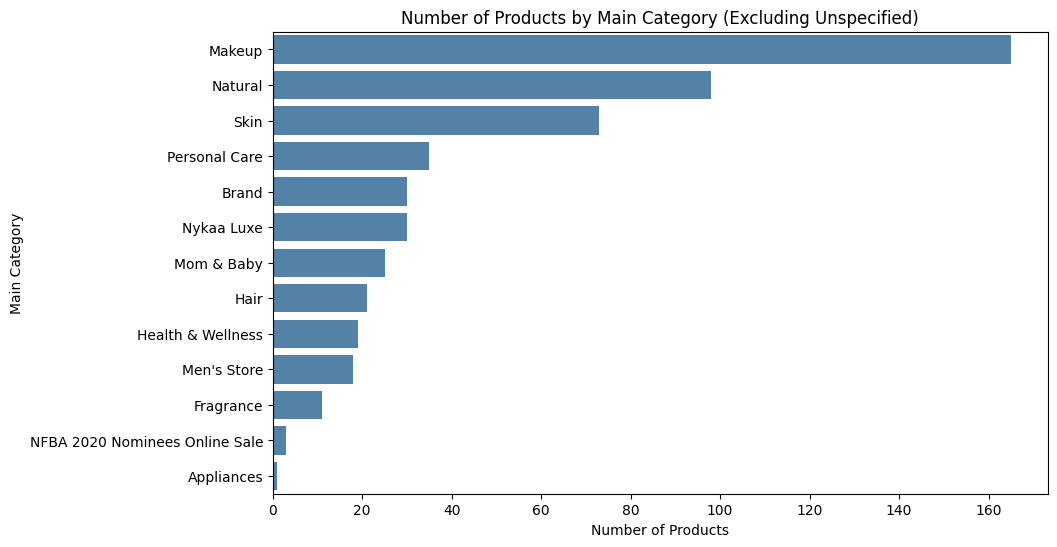

In [22]:
# Chart - 3 visualization code
category_data = df[df['Main Category'] != 'Not Specified']
category_counts = category_data['Main Category'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=category_counts.values, y=category_counts.index, color='steelblue')
plt.title('Number of Products by Main Category (Excluding Unspecified)')
plt.xlabel('Number of Products')
plt.ylabel('Main Category')

##### 1. Why did you pick the specific chart?

A horizontal bar chart is well-suited for comparing counts across categorical values, especially when category names are long (like "Health & Wellness"). It clearly shows which categories dominate the catalog and which are underrepresented, without the clutter of a pie chart when there are several categories.

##### 2. What is/are the insight(s) found from the chart?

The catalog is likely dominated by one or two major categories (most likely Makeup), with other categories like Health & Wellness, Skincare, or Haircare making up smaller shares.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Makeup overwhelmingly dominates, this signals where the bulk of catalog investment, marketing, and inventory currently sits — but it also means the business may be over-concentrated in one category, creating risk if consumer trends shift toward wellness or skincare (categories currently gaining popularity in the beauty industry).
* Underrepresented categories represent a growth opportunity — expanding catalog depth there could capture new customer segments without directly competing in the already-saturated Makeup space.

#### Chart - 4

Text(0, 0.5, 'Product Brand')

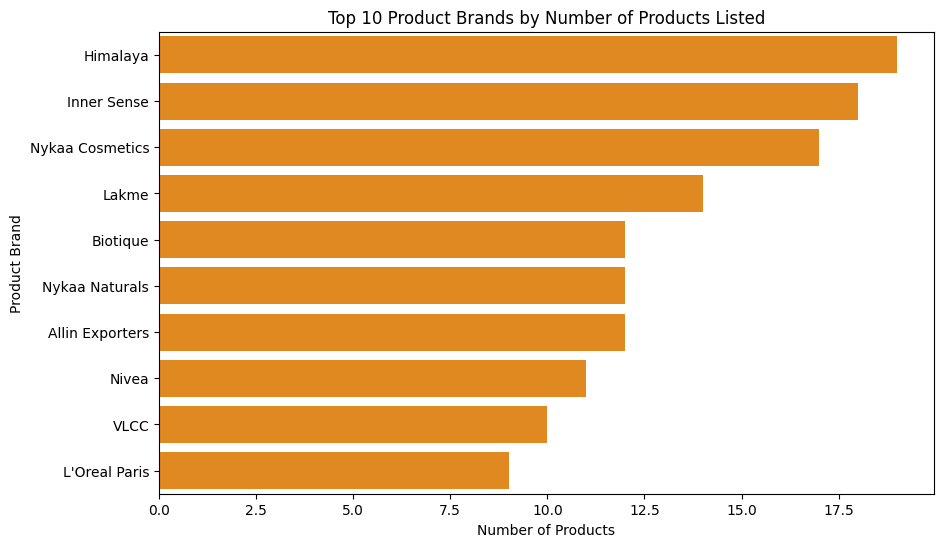

In [23]:
# Chart - 4 visualization code
top_brands = df['Product Brand'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_brands.values, y=top_brands.index, color='darkorange')
plt.title('Top 10 Product Brands by Number of Products Listed')
plt.xlabel('Number of Products')
plt.ylabel('Product Brand')

##### 1. Why did you pick the specific chart?

With many unique brands in the dataset, showing all of them would be cluttered and unreadable. Limiting to the top 10 by product count highlights which brands have the strongest presence on the platform, using a horizontal bar chart for easy label readability.

##### 2. What is/are the insight(s) found from the chart?

no single brand dominates overwhelmingly — the top 10 counts are fairly close together (9 to 19), rather than one brand having a massive lead.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Nykaa's own private labels (Nykaa Cosmetics at #3, Nykaa Naturals at #6) rank highly — this shows the platform is actively pushing its in-house brands, which typically carry higher profit margins than third-party brands. This is a good sign for Nykaa's own profitability strategy.
* Himalaya and Inner Sense having the most products suggests these brands are heavily invested in the Nykaa platform (wide catalog presence) — these are strong candidates for co-marketing or exclusive-launch partnerships, since they already have platform reach.

#### Chart - 5

Text(0.5, 0, 'Number of Reviews')

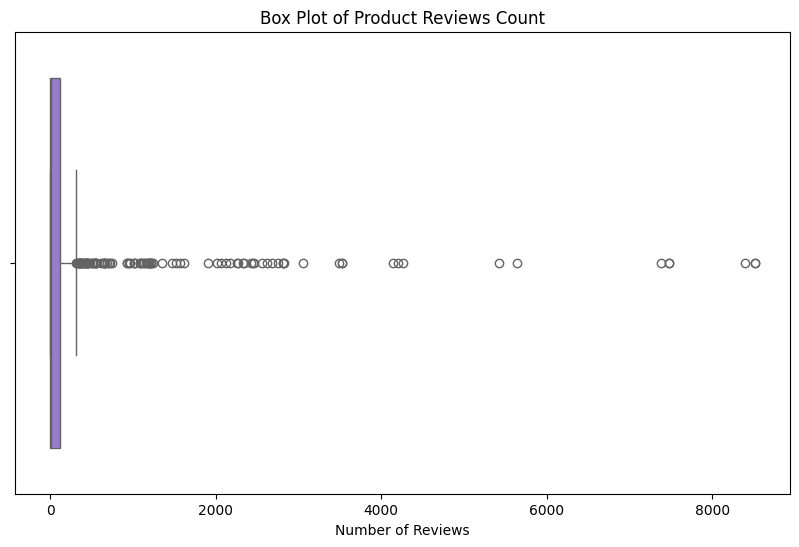

In [24]:
# Chart - 5 visualization code
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Product Reviews Count'], color='mediumpurple')
plt.title('Box Plot of Product Reviews Count')
plt.xlabel('Number of Reviews')

##### 1. Why did you pick the specific chart?

A box plot is well-suited for skewed data like Product Reviews Count, since it summarizes the distribution using the median, quartiles, and clearly flags outliers as individual points — instead of squashing everything into one dominant bar like a histogram does.

##### 2. What is/are the insight(s) found from the chart?

The box itself (middle 50% of products) is likely squeezed very close to 0, since most products have few or no reviews. Meanwhile, a long tail of outlier points extending far to the right represents the small number of highly-reviewed bestseller products

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The tight box near zero confirms that typical products get very little engagement, reinforcing the need for review-generation strategies across most of the catalog.

#### Chart - 6

Text(0, 0.5, 'Number of Reviews')

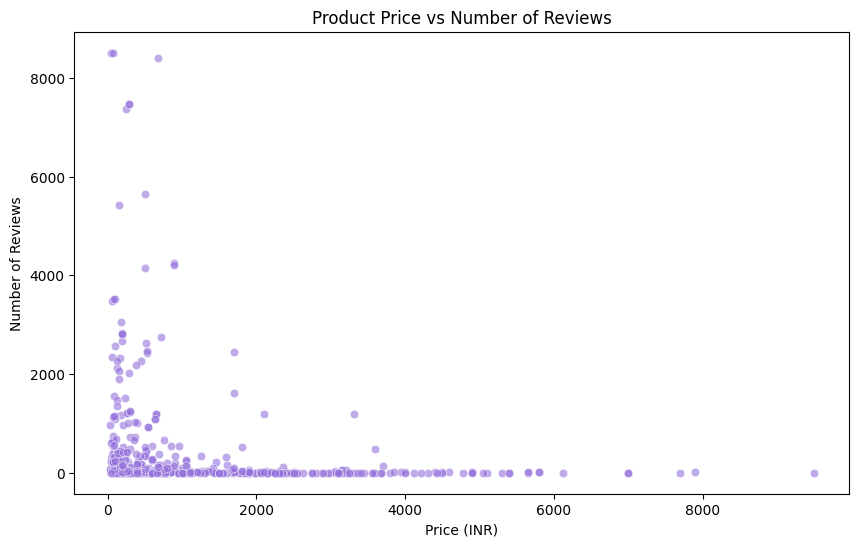

In [25]:
# Chart - 6 visualization code
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Product Price', y='Product Reviews Count', color='mediumpurple', alpha=0.6)
plt.title('Product Price vs Number of Reviews')
plt.xlabel('Price (INR)')
plt.ylabel('Number of Reviews')

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for spotting relationships between two continuous variables. Instead of just showing review counts alone (which was too skewed to read as a histogram), plotting it against price reveals whether cheaper or more expensive products tend to attract more reviews — turning this into a more insightful, two-variable view rather than a single skewed distribution.

##### 2. What is/are the insight(s) found from the chart?

High review counts only happen at low prices, while high prices almost always mean low/no reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a real risk for premium revenue growth: if pricier products can't break out of the "low review" zone, they'll continue to underperform regardless of quality, since customers rely heavily on reviews before buying higher-priced items.

A possible strategy: use targeted review-generation campaigns or free trials specifically for premium products, since they clearly aren't building trust organically the way budget products do.

#### Chart - 7

/tmp/ipykernel_1230/2539588725.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_by_price = df.groupby('Price Range')['Product Rating'].mean().reset_index()


Text(0, 0.5, 'Average Rating (out of 5)')

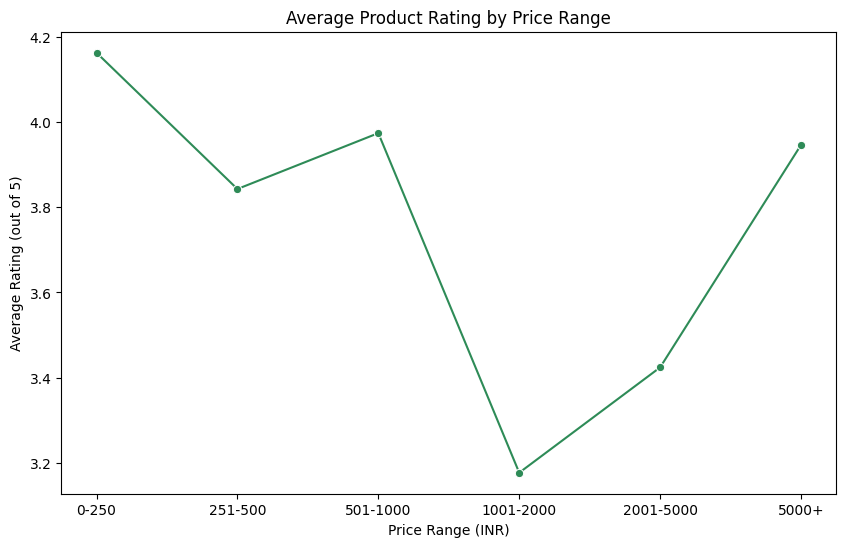

In [26]:
# Chart - 7 visualization code
avg_rating_by_price = df.groupby('Price Range')['Product Rating'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=avg_rating_by_price, x='Price Range', y='Product Rating', marker='o', color='seagreen')
plt.title('Average Product Rating by Price Range')
plt.xlabel('Price Range (INR)')
plt.ylabel('Average Rating (out of 5)')

##### 1. Why did you pick the specific chart?

A line plot is effective for showing a trend across ordered categories — since price ranges naturally go from low to high, this chart makes it easy to see at a glance whether average rating rises, falls, or stays flat as price increases

##### 2. What is/are the insight(s) found from the chart?

The cheapest products (₹0-250) have the highest average rating (4.16) in the entire catalog. Ratings then gradually dip through the ₹251–1000 ranges (3.84–3.97), before dropping sharply at ₹1001–2000 (3.17) — the lowest point on the chart. Ratings then recover somewhat for ₹2001–5000 (3.43) and ₹5000+ (3.95), but never fully return to the initial high seen in the cheapest bracket.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The ₹1001–2000 range is a clear problem zone — customers rate these products noticeably worse than any other price bracket. This is the range most likely to disappoint on a value-for-money basis: not cheap enough to feel like a steal, not premium enough to justify a "luxury" experience. This segment needs urgent attention — either through quality improvement, repricing, or repositioning.

#### Chart - 8

Text(0, 0.5, 'Main Category')

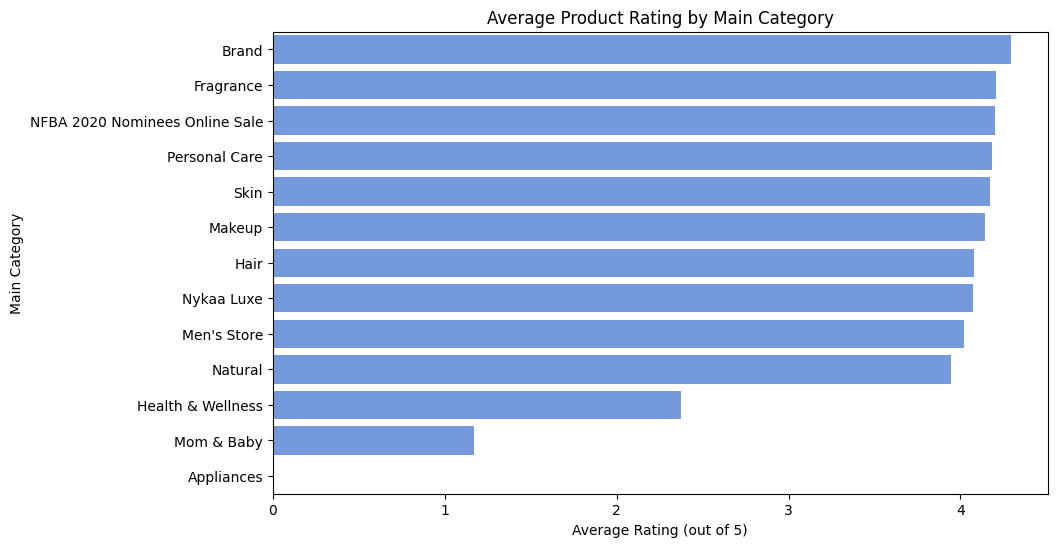

In [27]:
# Chart - 8 visualization code
category_data = df[df['Main Category'] != 'Not Specified']
avg_rating_category = category_data.groupby('Main Category')['Product Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating_category.values, y=avg_rating_category.index, color='cornflowerblue')
plt.title('Average Product Rating by Main Category')
plt.xlabel('Average Rating (out of 5)')
plt.ylabel('Main Category')

##### 1. Why did you pick the specific chart?

A bar chart is effective for comparing a single averaged metric (rating) across multiple categories side-by-side. This directly answers a practical business question: which product categories are customers happiest with, and which underperform?

##### 2. What is/are the insight(s) found from the chart?

Most categories cluster in a healthy 4.0–4.3 rating range — Brand, Fragrance, Personal Care, Skin, Makeup, Hair, Nykaa Luxe, and Men's Store all perform similarly well, suggesting consistent customer satisfaction across the bulk of the catalog. Three categories stand out as clear underperformers: Health & Wellness (2.4), Mom & Baby (1.2), and Appliances (0).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Consistent 4.0+ ratings across core categories (Makeup, Skin, Hair, Personal Care) confirm these segments are healthy and safe to continue investing in — no category-specific quality concerns here.

#### Chart - 9

Text(0, 0.5, 'Main Category')

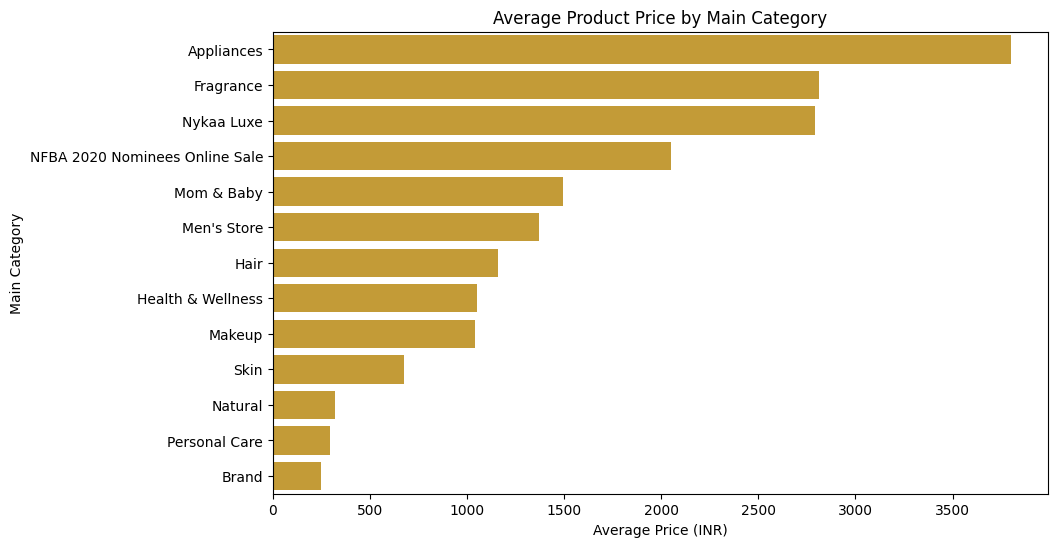

In [37]:
# Chart - 9 visualization code
category_data = df[df['Main Category'] != 'Not Specified']
avg_price_category = category_data.groupby('Main Category')['Product Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_price_category.values, y=avg_price_category.index, color='goldenrod')
plt.title('Average Product Price by Main Category')
plt.xlabel('Average Price (INR)')
plt.ylabel('Main Category')

##### 1. Why did you pick the specific chart?

This chart directly compares average pricing across categories, answering a key business question: which categories command premium pricing, and which are positioned as budget segments? It's a useful complement to Chart 8 (rating by category) — together they show whether a category's price level matches its customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Appliances (₹3800), Fragrance (₹2800), and Nykaa Luxe (₹2800) are the most expensive categories on average, while Brand, Personal Care, and Natural (₹250–320) are the cheapest. There's a clear pricing hierarchy

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The Appliances category is a high-risk blind spot: it's priced like a premium category but has zero proven customer satisfaction data. This needs urgent attention — either the catalog here is too new/thin to judge (likely, given Chart 8 showed it may have almost no products), or it's a category quietly underperforming despite premium pricing.

#### Chart - 10

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Allin Exporters'),
  Text(1, 0, 'Biotique'),
  Text(2, 0, 'Himalaya'),
  Text(3, 0, 'Inner Sense'),
  Text(4, 0, "L'Oreal Paris"),
  Text(5, 0, 'Lakme'),
  Text(6, 0, 'Nivea'),
  Text(7, 0, 'Nykaa Cosmetics'),
  Text(8, 0, 'Nykaa Naturals'),
  Text(9, 0, 'VLCC')])

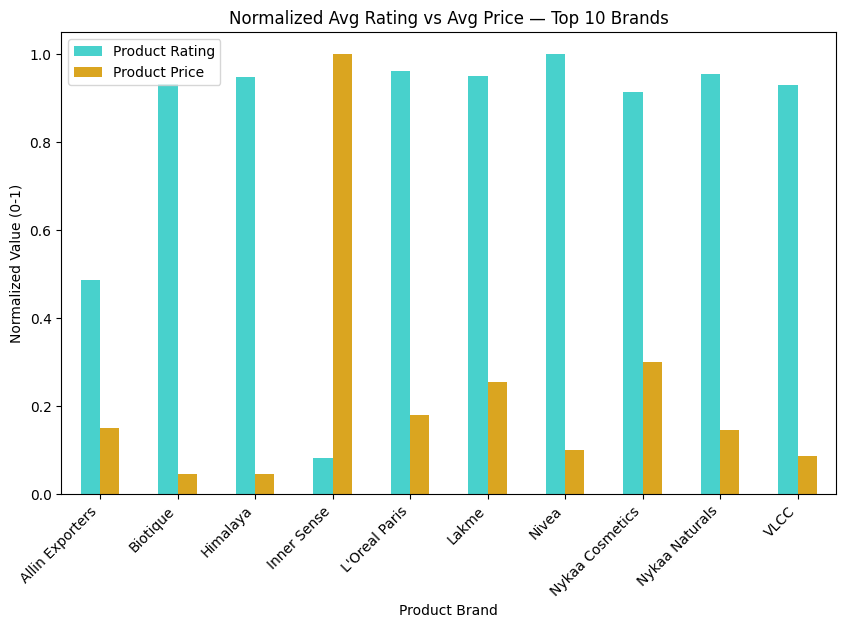

In [41]:
# Chart - 10 visualization code
top_brands_list = df['Product Brand'].value_counts().head(10).index
top_brand_data = df[df['Product Brand'].isin(top_brands_list)]

brand_summary = top_brand_data.groupby('Product Brand')[['Product Rating', 'Product Price']].mean()
brand_summary_norm = brand_summary / brand_summary.max()  # scale both to 0-1 for fair comparison

brand_summary_norm.plot(kind='bar', figsize=(10,6), color=['mediumturquoise', 'goldenrod'])
plt.title('Normalized Avg Rating vs Avg Price — Top 10 Brands')
plt.ylabel('Normalized Value (0-1)')
plt.xticks(rotation=45, ha='right')

##### 1. Why did you pick the specific chart?

A grouped bar chart puts average rating and average price side-by-side for each top brand, making it easy to visually spot brands where price and customer satisfaction are aligned — versus brands where one is high and the other isn't.

##### 2. What is/are the insight(s) found from the chart?

Almost every top-10 brand shows a high, tightly-clustered rating bar (0.90–1.0 normalized) — meaning nearly all major brands are well-rated by customers, regardless of price. Inner Sense is the dramatic outlier: it has the highest average price (normalized to 1.0, tallest gold bar) among all top brands, but its rating bar is by far the lowest (0.08) — a severe mismatch between what customers pay and how satisfied they are. Allin Exporters also stands out with a noticeably lower rating (0.49) than every other brand, despite a relatively low price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Inner Sense is a serious red flag. It's the most expensive brand in the top 10 by average price, yet has by far the weakest customer satisfaction. This is the clearest value-mismatch finding in the entire analysis — customers are paying a premium and coming away dissatisfied. This brand needs an urgent quality/pricing review; continuing to promote it at current pricing risks real damage to platform trust, especially since it's also a top-3 brand by product count

#### Chart - 11

Text(0.5, 1.0, 'Average Rating by Price Tier, across Categories')

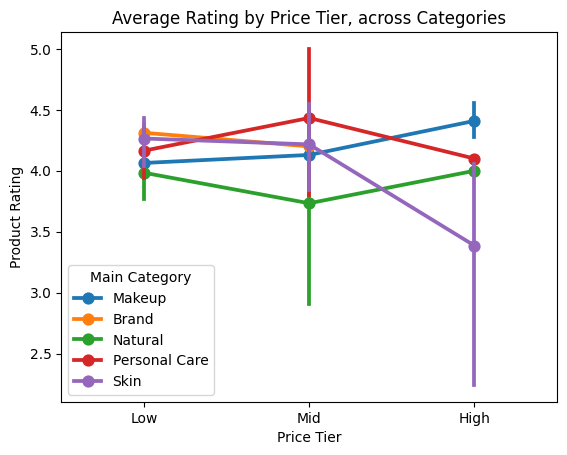

In [45]:
# Chart - 11 visualization code
category_data = df[df['Main Category'] != 'Not Specified']
top_categories = category_data['Main Category'].value_counts().head(5).index
plot_data = category_data[category_data['Main Category'].isin(top_categories)].copy()
plot_data['Price Tier'] = pd.cut(plot_data['Product Price'], bins=[0, 500, 2000, plot_data['Product Price'].max()], labels=['Low', 'Mid', 'High'])

sns.pointplot(data=plot_data, x='Price Tier', y='Product Rating', hue='Main Category')
plt.title('Average Rating by Price Tier, across Categories')

##### 1. Why did you pick the specific chart?

A point plot condenses three variables — category, price tier, and average rating — into simple connected lines, one per category. It's compact code-wise while still clearly showing whether rating rises, falls, or stays flat across price tiers, separately for each category.

##### 2. What is/are the insight(s) found from the chart?

Most categories — Makeup, Personal Care, and Natural — hold relatively steady ratings across Low, Mid, and High price tiers, with Makeup even slightly improving at the High tier. Brand only appears at the Low tier. Skin is the clear outlier: it starts strong at Low/Mid but drops sharply at the High tier, with a wide confidence interval — signaling both a real rating drop and high inconsistency among expensive Skin products.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Skin category's High-tier products are the specific problem area underlying the earlier price-rating dip seen in Chart 7 — expensive skincare products are not delivering on customer expectations. This needs a targeted product/quality review of premium Skin listings specifically (ingredients, packaging, marketing claims vs. actual results)

#### Chart - 12

Text(0, 0.5, 'Number of Products')

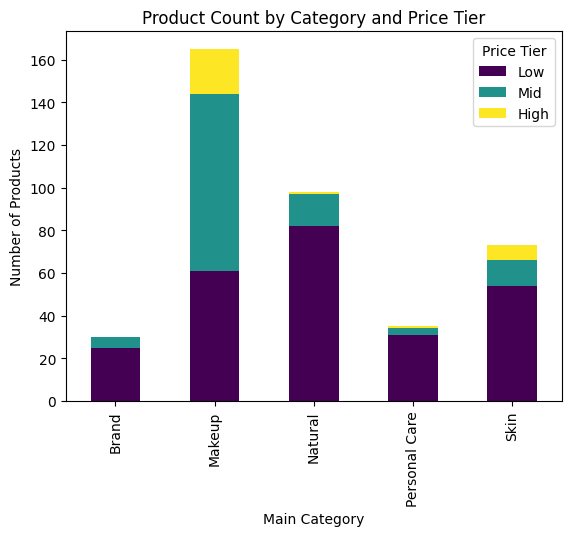

In [47]:
# Chart - 12 visualization code
category_data = df[df['Main Category'] != 'Not Specified']
top_categories = category_data['Main Category'].value_counts().head(5).index
plot_data = category_data[category_data['Main Category'].isin(top_categories)].copy()
plot_data['Price Tier'] = pd.cut(plot_data['Product Price'], bins=[0, 500, 2000, plot_data['Product Price'].max()], labels=['Low', 'Mid', 'High'])

pd.crosstab(plot_data['Main Category'], plot_data['Price Tier']).plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Product Count by Category and Price Tier')
plt.ylabel('Number of Products')

##### 1. Why did you pick the specific chart?

A stacked bar chart brings together three variables — category, price tier, and product count — showing how each category's catalog is composed across Low/Mid/High price tiers in a single, compact view. This adds useful context to Chart 11: a rating dip at a certain tier matters more if that tier represents a large chunk of the category's products, versus just a handful.

##### 2. What is/are the insight(s) found from the chart?

Makeup dominates the catalog by far (165 products) with a healthy mix across all three price tiers, followed by Natural (98, mostly Low tier), Skin (73), Brand (30), and Personal Care (35). Critically — Skin's "High" price tier is a small yellow slice at the very top of its bar, roughly 8–10 products out of 73. This confirms that the sharp rating drop seen in Chart 11 for High-tier Skin products (3.4 average, wide error bar) is based on a very small sample size, not a catalog-wide quality failure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Makeup's balanced spread across all three tiers, combined with its strong ratings at every tier (from Chart 11), confirms it as the most robust and reliable category in the catalog — safe to scale further at any price point.

#### Chart - 13

Text(0.5, 1.0, 'Average Rating: Top Brands across Categories')

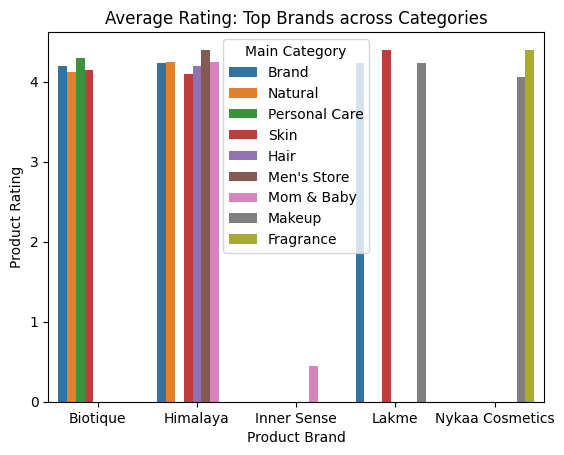

In [48]:
# Chart - 13 visualization code
top_brands_list = df['Product Brand'].value_counts().head(5).index
plot_data = df[df['Product Brand'].isin(top_brands_list) & (df['Main Category'] != 'Not Specified')]

summary = plot_data.groupby(['Product Brand', 'Main Category'])['Product Rating'].mean().reset_index()

sns.barplot(data=summary, x='Product Brand', y='Product Rating', hue='Main Category')
plt.title('Average Rating: Top Brands across Categories')

##### 1. Why did you pick the specific chart?

This grouped bar chart brings together three variables — brand, category, and average rating — showing how each top brand's rating varies across the different categories it sells in. It's a lighter-weight alternative to the heatmap, useful for directly comparing bar heights rather than reading color intensity.

##### 2. What is/are the insight(s) found from the chart?

Biotique and Himalaya rate consistently well (4.0–4.4) across all their categories. Inner Sense only sells in Mom & Baby, with a rating of just 0.4 — extremely low.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This pinpoints the exact source of Inner Sense's poor performance (seen earlier in Chart 10) and Mom & Baby's low category rating (Chart 8): Inner Sense's Mom & Baby line specifically. Given how trust-sensitive baby products are, this needs urgent review — check for real quality issues.

#### Chart - 14 - Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Variables')

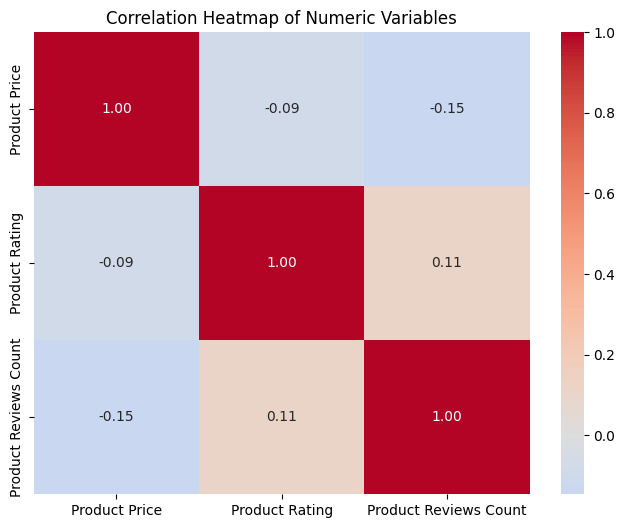

In [50]:
# Correlation Heatmap visualization code
numeric_cols = ['Product Price', 'Product Rating', 'Product Reviews Count']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to check linear relationships between all numeric variables at once. It quantifies what we've been exploring visually across earlier charts (price vs. rating, price vs. reviews) with a single number, confirming whether those patterns are statistically meaningful or just visual noise.

##### 2. What is/are the insight(s) found from the chart?

All three correlations are very weak: Price–Rating is -0.09, Price–Reviews Count is -0.15, and Rating–Reviews Count is 0.11. None of these come close to a meaningful linear relationship.

#### Chart - 15 - Pair Plot

In [34]:
# Pair Plot visualization code

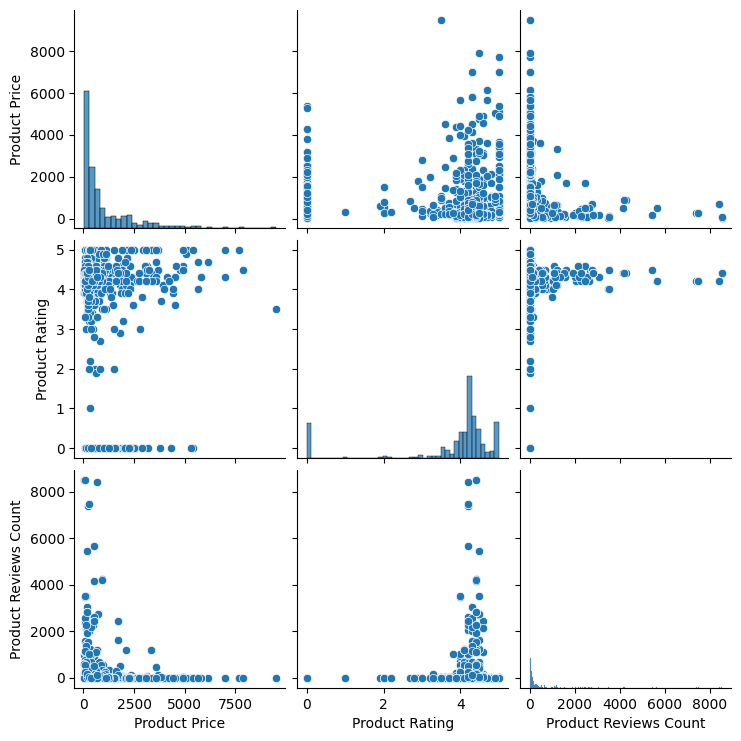

In [51]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise relationship between the numeric variables (Price, Rating, Reviews Count) in one grid, alongside each variable's individual distribution on the diagonal. It's a comprehensive final check — visually confirming the weak correlations we just saw numerically in the heatmap, while also revealing any non-linear patterns a correlation coefficient alone might miss.

##### 2. What is/are the insight(s) found from the chart?

The diagonal plots confirm the skew we've seen throughout: Price is heavily right-skewed (most products cluster near ₹0–2000), Rating shows a clear bimodal pattern (a spike at 0 for unrated products, and a strong cluster at 4–4.5), and Reviews Count is extremely right-skewed (most products near 0, a long thin tail of bestsellers). The Price-vs-Reviews scatter clearly shows all the high-review products (2000–8500) sitting only at low prices — confirming the "funnel" pattern from Chart 6. The Price-vs-Rating scatter shows ratings spread across all price levels, confirming price doesn't drive rating.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. Fix Inner Sense's Mom & Baby line urgently — extremely low rating (0.4) despite high price.
2. Review premium Skin products (₹1000+) — ratings dip noticeably here.
3. Boost reviews for expensive products — they get less engagement and trust.
4. Keep investing in budget products (₹0–500) — highest ratings and engagement.
5. Grow thin categories (Mom & Baby, Wellness, Appliances) before trusting their ratings — too few products currently.
6. Don't equate price with quality — the two show almost no correlation.
7. Prioritize consistent brands like Himalaya and Biotique for partnerships.

# **Conclusion**

This analysis of 610 Nykaa products shows the catalog is dominated by affordable products (₹0–500), which also have the highest ratings and engagement — Nykaa's clear strength.
Price does not predict rating (correlation ≈ -0.09). Some key mismatches found:

₹1000–2000 products show a rating dip.
High-priced Skin products underperform.
Inner Sense (priciest top brand) has very low ratings, driven by its Mom & Baby line (~0.4) — needs urgent attention.

Expensive products also get far fewer reviews, suggesting a trust/visibility gap, not low demand. Categories like Mom & Baby, Wellness, and Appliances have too few products to trust their ratings yet. Makeup, Skin, and Hair are strong, well-rated categories, and Himalaya, Biotique are the most consistent brands.
Recommendation: keep investing in the budget segment, fix the Inner Sense/Mom & Baby issue, boost reviews for premium products, and grow thin categories before trusting their numbers. Price and quality should be treated as separate levers.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***